# Semiconductor Manufacturing Process Classification using Machine Learning

## Project Overview

This project aims to predict whether a semiconductor manufacturing process will pass or fail using machine learning techniques. Three supervised learning algorithms—Random Forest, Gaussian Naive Bayes, and Support Vector Machine (SVM)—are trained, evaluated, and compared. Hyperparameter tuning using GridSearchCV is performed to improve the best-performing model, and the final optimized model is saved for future predictions.

### Objectives

- Import and explore the dataset
- Perform data cleaning and missing value treatment
- Conduct exploratory data analysis (EDA)
- Handle class imbalance using SMOTE
- Train and evaluate multiple machine learning models
- Optimize the best model using GridSearchCV
- Save the final trained model

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/Semiconductor_Project')

['Capstone 2 Corizo (1) (2).pdf', 'signal-data.csv']

In [3]:
file_path = '/content/drive/MyDrive/Semiconductor_Project/signal-data.csv'
print(file_path)

/content/drive/MyDrive/Semiconductor_Project/signal-data.csv


# 1. Import Required Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load the Dataset

In [5]:
df = pd.read_csv(file_path)

# 3. Exploratory Data Analysis (EDA)

In [6]:
df.shape

(1567, 592)

In [7]:
df.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB


In [9]:
df.columns

Index(['Time', '0', '1', '2', '3', '4', '5', '6', '7', '8',
       ...
       '581', '582', '583', '584', '585', '586', '587', '588', '589',
       'Pass/Fail'],
      dtype='object', length=592)

In [10]:
df.dtypes[df.dtypes == 'object']

,0
Time,object


In [11]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
293,1429
292,1429
157,1429
158,1429
492,1341
220,1341
85,1341
358,1341
518,1018
382,1018


In [12]:
missing_percentage = (df.isnull().sum() / len(df))*100
missing_percentage.sort_values(ascending=False).head(20)

,0
293,91.193363
292,91.193363
157,91.193363
158,91.193363
492,85.577537
220,85.577537
85,85.577537
358,85.577537
518,64.964901
382,64.964901


In [13]:
df['Pass/Fail'].value_counts()

,count
Pass/Fail,
-1,1463
1,104


In [14]:
df.isnull().sum().sum()

np.int64(41951)

In [15]:
(df.isnull().sum()>0).sum()

np.int64(538)

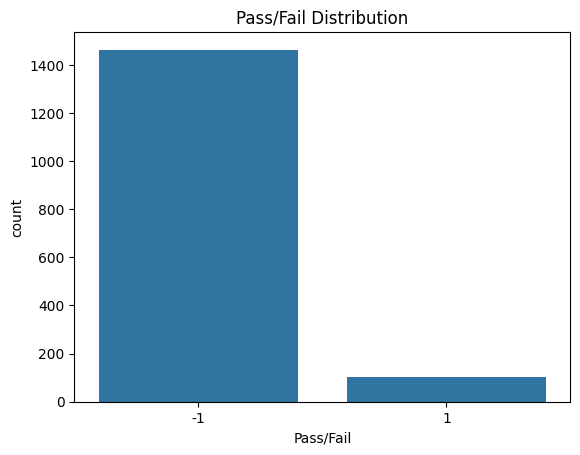

In [16]:
sns.countplot(x='Pass/Fail', data=df)
plt.title('Pass/Fail Distribution')
plt.show()

In [17]:
high_missing_cols = missing_percentage[missing_percentage > 50]
high_missing_cols

,0
72,50.670070
73,50.670070
85,85.577537
109,64.964901
110,64.964901
111,64.964901
157,91.193363
158,91.193363
220,85.577537
244,64.964901


In [18]:
len(high_missing_cols)

28

In [19]:
df[high_missing_cols.index].describe().T

,count,mean,std,min,25%,50%,75%,max
72,773.0,150.361552,18.388481,-59.4777,145.305300,152.29720,158.437800,175.4132
73,773.0,468.020404,17.629886,456.0447,464.458100,466.08170,467.889900,692.4256
85,226.0,0.112783,0.002928,0.1053,0.110725,0.11355,0.114900,0.1184
109,549.0,0.979993,0.008695,0.7848,0.978800,0.98100,0.982300,0.9842
110,549.0,101.318253,1.880087,88.1938,100.389000,101.48170,102.078100,106.9227
111,549.0,231.818898,2.105318,213.0083,230.373800,231.20120,233.036100,236.9546
157,138.0,0.047104,0.039538,0.0118,0.027050,0.03545,0.048875,0.2876
158,138.0,1039.650738,406.848810,234.0996,721.675050,1020.30005,1277.750125,2505.2998
220,226.0,0.009213,0.001989,0.0057,0.007800,0.00895,0.010300,0.0240
244,549.0,0.005755,0.084618,0.0003,0.001200,0.00170,0.002600,1.9844


# 4. Data Cleaning and Missing Value Handling

In [20]:
df = df.drop('Time',axis=1)

In [21]:
df.shape

(1567, 591)

In [22]:
df_backup = df.copy()

In [23]:
df = df.drop(columns=high_missing_cols.index)

In [24]:
df.shape

(1567, 563)

In [25]:
df.isnull().sum().sum()

np.int64(11683)

In [26]:
df = df.fillna(df.median())

In [27]:
df.isnull().sum().sum()

np.int64(0)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 563 entries, 0 to Pass/Fail
dtypes: float64(562), int64(1)
memory usage: 6.7 MB


# 5. Statistical Analysis and Visualization

In [29]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,577,582,583,584,585,586,587,588,589,Pass/Fail
count,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.0,1567.000000,1567.000000,1567.000000,1567.000000,...,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000
mean,3014.441551,2495.866110,2200.551958,1395.383474,4.171281,100.0,101.116476,0.121825,1.462860,-0.000842,...,16.642363,0.500096,0.015317,0.003846,3.067628,0.021458,0.016474,0.005283,99.652345,-0.867262
std,73.480841,80.228143,29.380973,439.837330,56.103721,0.0,6.209385,0.008936,0.073849,0.015107,...,12.485267,0.003403,0.017174,0.003719,3.576899,0.012354,0.008805,0.002866,93.864558,0.498010
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,100.0,82.131100,0.000000,1.191000,-0.053400,...,4.582000,0.477800,0.006000,0.001700,1.197500,-0.016900,0.003200,0.001000,0.000000,-1.000000
25%,2966.665000,2452.885000,2181.099950,1083.885800,1.017700,100.0,97.937800,0.121100,1.411250,-0.010800,...,11.501550,0.497900,0.011600,0.003100,2.306500,0.013450,0.010600,0.003300,44.368600,-1.000000
50%,3011.490000,2499.405000,2201.066700,1285.214400,1.316800,100.0,101.512200,0.122400,1.461600,-0.001300,...,13.817900,0.500200,0.013800,0.003600,2.757650,0.020500,0.014800,0.004600,71.900500,-1.000000
75%,3056.540000,2538.745000,2218.055500,1590.169900,1.518800,100.0,104.530000,0.123800,1.516850,0.008400,...,17.080900,0.502350,0.016500,0.004100,3.294950,0.027600,0.020300,0.006400,114.749700,-1.000000
max,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,100.0,129.252200,0.128600,1.656400,0.074900,...,96.960100,0.509800,0.476600,0.104500,99.303200,0.102800,0.079900,0.028600,737.304800,1.000000


In [30]:
df.duplicated().sum()

np.int64(0)

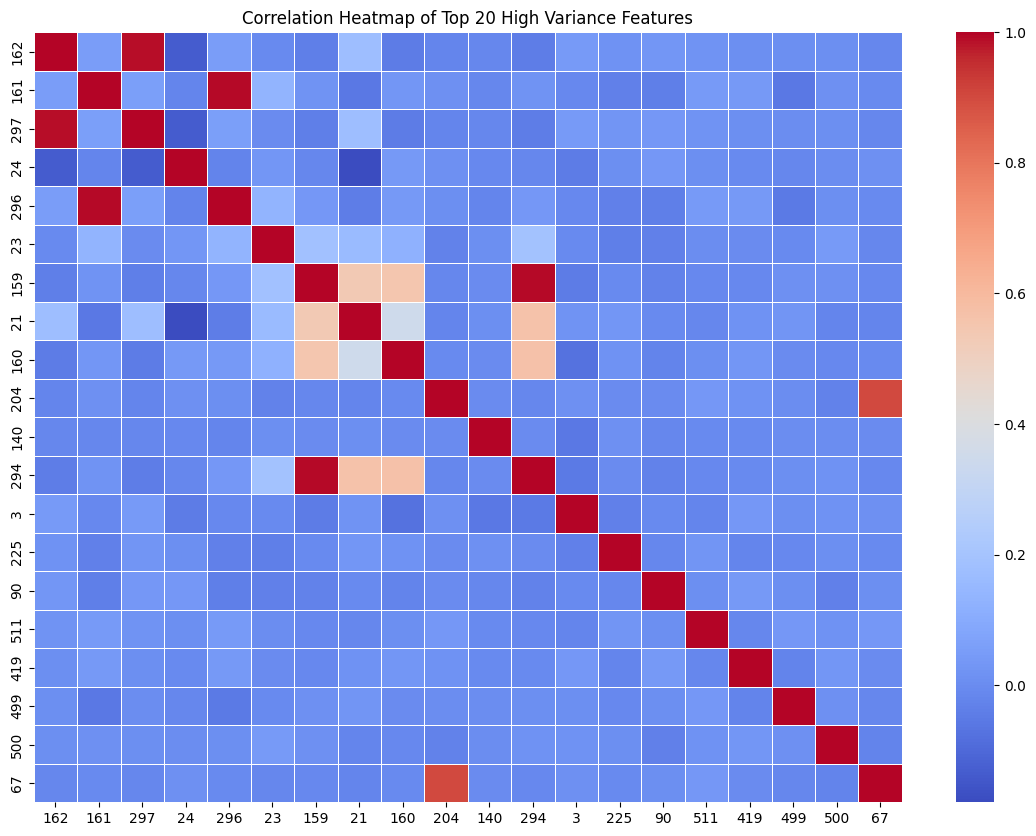

In [31]:
x = df.drop('Pass/Fail', axis=1)

variance = x.var()
top20_features = variance.sort_values(ascending=False).head(20).index

plt.figure(figsize=(14,10))
sns.heatmap(df[top20_features].corr(), annot=False, cmap='coolwarm',linewidths=0.5)
plt.title('Correlation Heatmap of Top 20 High Variance Features')
plt.show()

# 6. Feature and Target Separation

In [32]:
x = df.drop('Pass/Fail', axis=1)
y = df['Pass/Fail']

print("Shape of Features (x):",x.shape)
print("Shape of Target (y):",y.shape)

Shape of Features (x): (1567, 562)
Shape of Target (y): (1567,)


# 7. Train-Test Split

In [33]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)
print("Training Feature:", x_train.shape)
print("Training Target:", y_train.shape)
print("Testing Feature:", x_test.shape)
print("Testing Target:", y_test.shape)

Training Feature: (1253, 562)
Training Target: (1253,)
Testing Feature: (314, 562)
Testing Target: (314,)


In [34]:
print("Training Set Class Distribution:")
print(y_train.value_counts())
print("\nTesting Set Class Distribution:")
print(y_test.value_counts())

Training Set Class Distribution:
Pass/Fail
-1    1170
 1      83
Name: count, dtype: int64

Testing Set Class Distribution:
Pass/Fail
-1    293
 1     21
Name: count, dtype: int64


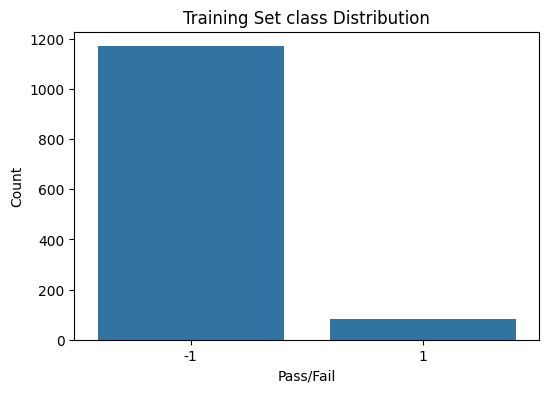

In [35]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.title("Training Set class Distribution")
plt.xlabel("Pass/Fail")
plt.ylabel("Count")

plt.show()

# 8. Handle Class Imbalance using SMOTE

In [36]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Pass/Fail
-1    1170
 1      83
Name: count, dtype: int64

After SMOTE:
Pass/Fail
-1    1170
 1    1170
Name: count, dtype: int64


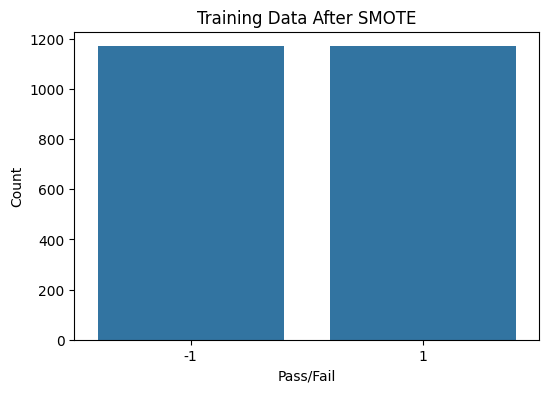

In [37]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train_smote)

plt.title("Training Data After SMOTE")
plt.xlabel("Pass/Fail")
plt.ylabel("Count")

plt.show()

# 9. Feature Scaling

In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_smote)
x_test_scaled = scaler.transform(x_test)

print("Training Data Shape:",x_train_scaled.shape)
print("Testing Data Shape:",x_test_scaled.shape)

Training Data Shape: (2340, 562)
Testing Data Shape: (314, 562)


# 10. Random Forest Model

In [39]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
    )
rf_model.fit(x_train_scaled, y_train_smote)

RandomForestClassifier(random_state=42)

In [40]:
rf_predictions = rf_model.predict(x_test_scaled)

In [41]:
from sklearn.metrics import accuracy_score
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy:{rf_accuracy:.4f}")

Random Forest Accuracy:0.9299


In [42]:
from sklearn.metrics import classification_report
print("Random Forest Classification Report:\n")
print(classification_report(y_test,rf_predictions))

Random Forest Classification Report:

              precision    recall  f1-score   support

          -1       0.93      1.00      0.96       293
           1       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



In [43]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,rf_predictions)

print ("Confussion Matrix:\n")
print(cm)

Confussion Matrix:

[[292   1]
 [ 21   0]]


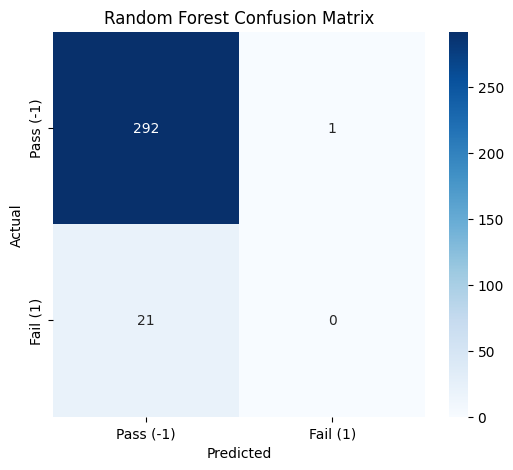

In [44]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pass (-1)', 'Fail (1)'],
    yticklabels=['Pass (-1)', 'Fail (1)']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

# 11. Gaussian Naive Bayes Model

In [45]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(x_train_scaled, y_train_smote)

GaussianNB()

In [46]:
nb_predictions = nb_model.predict(x_test_scaled)

In [47]:
nb_accuracy = accuracy_score(y_test,nb_predictions)
print(f"Naive Bayes Accuracy:{nb_accuracy:.4f}")

Naive Bayes Accuracy:0.2548


In [48]:
from sklearn.metrics import classification_report

print("Naive Bayes Classification Report:\n")
print(classification_report(y_test, nb_predictions))

Naive Bayes Classification Report:

              precision    recall  f1-score   support

          -1       0.95      0.21      0.35       293
           1       0.07      0.86      0.13        21

    accuracy                           0.25       314
   macro avg       0.51      0.53      0.24       314
weighted avg       0.89      0.25      0.33       314



In [49]:
from sklearn.metrics import confusion_matrix

nb_cm = confusion_matrix(y_test, nb_predictions)

print("Confusion Matrix:\n")
print(nb_cm)

Confusion Matrix:

[[ 62 231]
 [  3  18]]


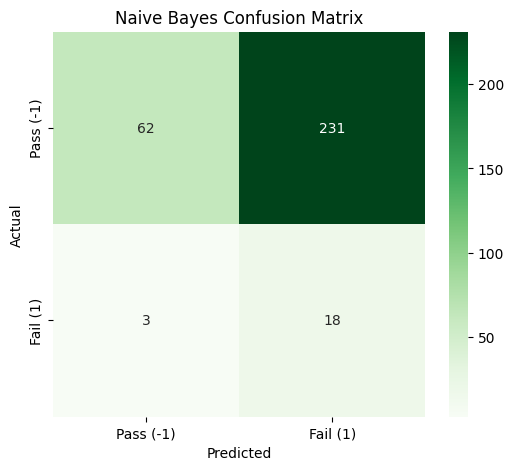

In [50]:
plt.figure(figsize=(6,5))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Pass (-1)', 'Fail (1)'],
    yticklabels=['Pass (-1)', 'Fail (1)']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

# 12. Support Vector Machine (SVM)

In [51]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(x_train_scaled, y_train_smote)

SVC(random_state=42)

In [52]:
svm_predictions = svm_model.predict(x_test_scaled)

In [53]:
svm_accuracy = accuracy_score(y_test,svm_predictions)
print(f"SVM Accuracy:{svm_accuracy:.4f}")

SVM Accuracy:0.9331


In [54]:
print("SVM Classification Report:\n")
print(classification_report(y_test, svm_predictions))

SVM Classification Report:

              precision    recall  f1-score   support

          -1       0.94      1.00      0.97       293
           1       0.50      0.05      0.09        21

    accuracy                           0.93       314
   macro avg       0.72      0.52      0.53       314
weighted avg       0.91      0.93      0.91       314



In [55]:
svm_cm = confusion_matrix(y_test, svm_predictions)

print("Confusion Matrix:\n")
print(svm_cm)

Confusion Matrix:

[[292   1]
 [ 20   1]]


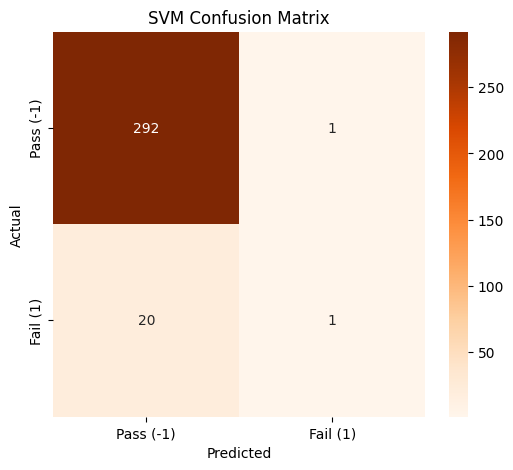

In [56]:
plt.figure(figsize=(6,5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Pass (-1)', 'Fail (1)'],
    yticklabels=['Pass (-1)', 'Fail (1)']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

# 13. Cross Validation

In [57]:
from sklearn.model_selection import cross_val_score

rf_cv_scores = cross_val_score(
    rf_model,
    x_train_scaled,
    y_train_smote,
    cv=5,
    scoring='accuracy'
)

print("Random Forest Cross Validation Scores:")
print(rf_cv_scores)

print(f"\nAverage Cross Validation Accuracy: {rf_cv_scores.mean():.4f}")

Random Forest Cross Validation Scores:
[0.97649573 1.         0.99358974 1.         0.99786325]

Average Cross Validation Accuracy: 0.9936


In [58]:
nb_cv_scores = cross_val_score(
    nb_model,
    x_train_scaled,
    y_train_smote,
    cv=5,
    scoring='accuracy'
)

print("Naive Bayes Cross Validation Scores:")
print(nb_cv_scores)

print(f"\nAverage Cross Validation Accuracy: {nb_cv_scores.mean():.4f}")

Naive Bayes Cross Validation Scores:
[0.58333333 0.60042735 0.58974359 0.6025641  0.63888889]

Average Cross Validation Accuracy: 0.6030


In [59]:
svm_cv_scores = cross_val_score(
    svm_model,
    x_train_scaled,
    y_train_smote,
    cv=5,
    scoring='accuracy'
)

print("SVM Cross Validation Scores:")
print(svm_cv_scores)

print(f"\nAverage Cross Validation Accuracy: {svm_cv_scores.mean():.4f}")

SVM Cross Validation Scores:
[0.99786325 0.9957265  0.99145299 0.99786325 0.9957265 ]

Average Cross Validation Accuracy: 0.9957


In [60]:
cv_results = pd.DataFrame({
    'Model': ['Random Forest', 'Naive Bayes', 'SVM'],
    'Average CV Accuracy': [
        rf_cv_scores.mean(),
        nb_cv_scores.mean(),
        svm_cv_scores.mean()
    ]
})
cv_results = cv_results.sort_values(
    by='Average CV Accuracy',
    ascending=False
)
cv_results

,Model,Average CV Accuracy
2,SVM,0.995726
0,Random Forest,0.993590
1,Naive Bayes,0.602991


# 14. Hyperparameter Tuning using GridSearchCV

In [61]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(x_train_scaled, y_train_smote)

GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 0.1, 0.01],
                         'kernel': ['rbf']},
             scoring='accuracy')

In [62]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(f"{grid_search.best_score_:.4f}")

print("\nBest Estimator:")
print(grid_search.best_estimator_)

Best Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Best Cross Validation Accuracy:
0.9962

Best Estimator:
SVC(C=10, random_state=42)


In [63]:
best_svm = grid_search.best_estimator_

best_predictions = best_svm.predict(x_test_scaled)

best_accuracy = accuracy_score(
    y_test,
    best_predictions
)

print(f"Optimized SVM Accuracy: {best_accuracy:.4f}")

Optimized SVM Accuracy: 0.9363


In [64]:
print("Optimized SVM Classification Report:\n")

print(classification_report(
    y_test,
    best_predictions
))

Optimized SVM Classification Report:

              precision    recall  f1-score   support

          -1       0.94      1.00      0.97       293
           1       1.00      0.05      0.09        21

    accuracy                           0.94       314
   macro avg       0.97      0.52      0.53       314
weighted avg       0.94      0.94      0.91       314



In [65]:
best_cm = confusion_matrix(
    y_test,
    best_predictions
)

print("Optimized SVM Confusion Matrix:\n")

print(best_cm)

Optimized SVM Confusion Matrix:

[[293   0]
 [ 20   1]]


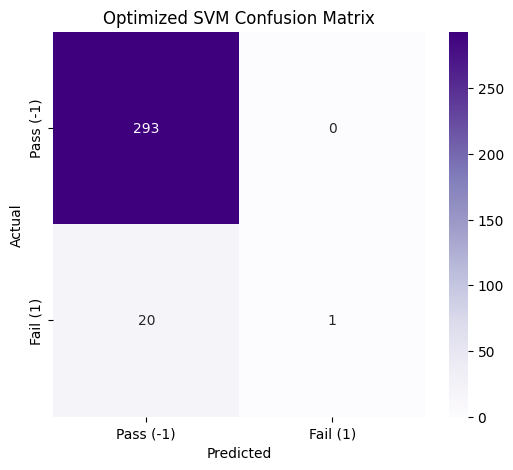

In [66]:
plt.figure(figsize=(6,5))

sns.heatmap(
    best_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Pass (-1)', 'Fail (1)'],
    yticklabels=['Pass (-1)', 'Fail (1)']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Optimized SVM Confusion Matrix")

plt.show()

# 15. Model Comparison

In [67]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Naive Bayes",
        "SVM",
        "Optimized SVM"
    ],

    "Test Accuracy": [
        rf_accuracy,
        nb_accuracy,
        svm_accuracy,
        best_accuracy
    ],

    "Cross Validation Accuracy": [
        rf_cv_scores.mean(),
        nb_cv_scores.mean(),
        svm_cv_scores.mean(),
        grid_search.best_score_
    ]
})

comparison = comparison.sort_values(
    by="Test Accuracy",
    ascending=False
)

comparison

,Model,Test Accuracy,Cross Validation Accuracy
3,Optimized SVM,0.936306,0.996154
2,SVM,0.933121,0.995726
0,Random Forest,0.929936,0.993590
1,Naive Bayes,0.254777,0.602991


# 16. Save the Best Model

In [68]:
best_model = comparison.iloc[0]

print("Best Model Selected:\n")

print(best_model)

Best Model Selected:

Model                        Optimized SVM
Test Accuracy                     0.936306
Cross Validation Accuracy         0.996154
Name: 3, dtype: object


In [69]:
import joblib

joblib.dump(best_svm, "best_svm_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# 17. Conclusion

## Conclusion

In this project, a machine learning-based classification system was developed to predict whether a semiconductor manufacturing process would pass or fail based on sensor measurements. Three supervised learning algorithms—Random Forest, Gaussian Naive Bayes, and Support Vector Machine (SVM)—were trained and evaluated.

Among all the models, the optimized SVM achieved the highest performance after hyperparameter tuning using GridSearchCV. The final optimized model was saved successfully and can be used for future predictions.

This project demonstrates the importance of data preprocessing, class balancing using SMOTE, feature scaling, model evaluation, and hyperparameter tuning in building an effective machine learning solution.